# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 8

### Zadanie 1

1. Wczytaj plik `mieszkania.csv` za pomocą jednej z poniższych bibliotek:
   - [`pandas`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) – funkcja `read_csv`,
   - [`numpy`](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html) – funkcja `genfromtxt`,
   - [`csv`](https://docs.python.org/3/library/csv.html) – funkcja `reader`.

2. Usuń nieprawidłowe dane, np. wiersze zawierające wartość `-` lub cenę równą `0`.

3. Zamień wartości liczbowe zapisane jako tekst na odpowiedni typ liczbowy.

4. Przedstaw **funkcję masy prawdopodobieństwa** wartości mieszkań w zależności od rodzaju *transakcji rynkowej*.  
   **Podpowiedź:** Skorzystaj z funkcji `displot` z biblioteki `seaborn` (jeśli nie masz biblioteki, zainstaluj ją poleceniem `pip install seaborn`).  
   Zwróć uwagę na argumenty: `x`, `hue`, `kind`, `fill`.

5. Wyświetl wszystkie trzy funkcje (dla ogółu, rynku pierwotnego i wtórnego) na jednym wykresie.

6. Zinterpretuj wyniki.

---

#### Informacje o zbiorze danych

- Dane dotyczą sprzedaży oraz cen nieruchomości i pochodzą z Głównego Urzędu Statystycznego (GUS), opracowane na podstawie danych z Rejestru Cen Nieruchomości (RCN), a do 31 lipca 2021 – z Rejestru Cen i Wartości Nieruchomości (RCiWN), prowadzonego przez starostwa powiatowe i prezydentów miast na prawach powiatu. Dane pochodzą z aktów notarialnych.
- Uwzględniono wyłącznie transakcje kupna/sprzedaży lokali mieszkalnych w budynkach wielorodzinnych (nie dotyczy domów jednorodzinnych), które miały miejsce w analizowanym okresie i zostały zarejestrowane w RCN przed datą przekazania danych do GUS.
- Dane dotyczą wyłącznie transakcji rynkowych, tj. sprzedaży na wolnym rynku (z wyłączeniem np. sprzedaży między osobami spokrewnionymi) oraz sprzedaży przetargowej.
- Podział na rynek pierwotny i wtórny:
  - **Rynek pierwotny**: sprzedaż na wolnym rynku przez osoby prawne, gdzie średnia cena 1 m² wynosi co najmniej 2 000 zł.
  - **Rynek wtórny**: pozostałe transakcje rynkowe, w tym sprzedaż przetargowa.
- W grudniu 2021 roku uzupełniono bazę BDL o dane za lata 2010–2014, obejmujące większą liczbę transakcji niż wcześniej publikowane dane.
- Brak danych od 2020 roku dla miasta Koszalin oraz częściowe braki dla Szczecina.

#### Oznaczenia w danych:

- `-` – brak informacji z powodu zmiany poziomu prezentacji, zmian w jednostkach terytorialnych lub cechach raportu,
- `n` – dane jeszcze niedostępne,
- `x` – brak informacji z powodu tajemnicy statystycznej lub niecelowości wypełnienia,
- `X` – brak danych ze względu na zmiany metodologiczne lub tajemnicę statystyczną.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
data = pd.read_csv('mieszkania.csv', sep=';')
data

,Kod,Nazwa,Transakcje rynkowe,Powierzchnia użytkowa lokali mieszkalnych,Rok,Wartosc,Jednostka miary,Atrybut
0,0,POLSKA,ogółem,ogółem,2010,4045,zł,
1,0,POLSKA,ogółem,ogółem,2011,4095,zł,
2,0,POLSKA,ogółem,ogółem,2012,3976,zł,
3,0,POLSKA,ogółem,ogółem,2013,4023,zł,
4,0,POLSKA,ogółem,ogółem,2014,4029,zł,
...,...,...,...,...,...,...,...,...
71455,3263000,Powiat m.Świnoujście,rynek wtórny,"od 80,1 m2",2017,4960,zł,
71456,3263000,Powiat m.Świnoujście,rynek wtórny,"od 80,1 m2",2018,5562,zł,
71457,3263000,Powiat m.Świnoujście,rynek wtórny,"od 80,1 m2",2019,6488,zł,
71458,3263000,Powiat m.Świnoujście,rynek wtórny,"od 80,1 m2",2020,7713,zł,


In [56]:
data.isin(["-","0"]).sum()

Kod                                              0
Nazwa                                            0
Transakcje rynkowe                               0
Powierzchnia użytkowa lokali mieszkalnych        0
Rok                                              0
Wartosc                                      20622
Jednostka miary                                  0
Atrybut                                          0
dtype: int64

In [57]:
# remove rows in "Wartosc" with: - and 0

data_ = data[~data["Wartosc"].isin(["-","0"])]
data_.shape

(50838, 8)

In [63]:
data_.columns
for col in data_.columns:
    print(f"{col}: {data_[col][0]}, type: {type(data_[col][0])}")
    
# data_.loc[:, "Wartosc"] = pd.to_numeric(data_.Wartosc)
data_ = data_.astype({'Wartosc': float})
print("\n\n")

for col in data_.columns:
    print(f"{col}: {data_[col][0]}, type: {type(data_[col][0])}")

Kod: 0, type: <class 'numpy.int64'>
Nazwa: POLSKA, type: <class 'str'>
Transakcje rynkowe: ogółem, type: <class 'str'>
Powierzchnia użytkowa lokali mieszkalnych: ogółem, type: <class 'str'>
Rok: 2010, type: <class 'numpy.int64'>
Wartosc: 4045.0, type: <class 'numpy.float64'>
Jednostka miary: zł, type: <class 'str'>
Atrybut:  , type: <class 'str'>



Kod: 0, type: <class 'numpy.int64'>
Nazwa: POLSKA, type: <class 'str'>
Transakcje rynkowe: ogółem, type: <class 'str'>
Powierzchnia użytkowa lokali mieszkalnych: ogółem, type: <class 'str'>
Rok: 2010, type: <class 'numpy.int64'>
Wartosc: 4045.0, type: <class 'numpy.float64'>
Jednostka miary: zł, type: <class 'str'>
Atrybut:  , type: <class 'str'>


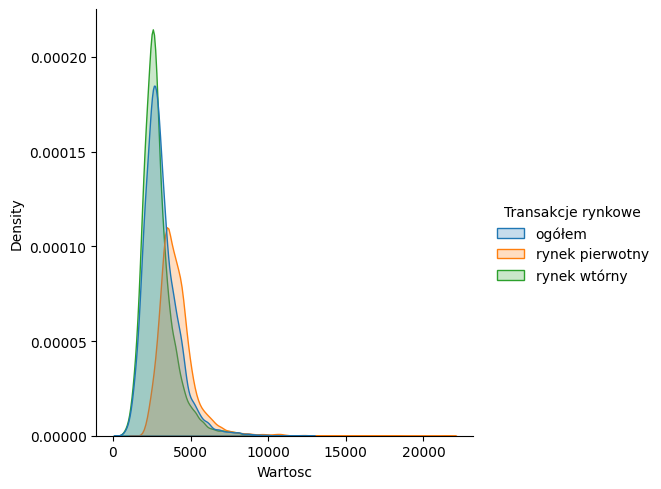

In [72]:
sns.displot(data=data_, x="Wartosc", kind="kde", hue="Transakcje rynkowe", fill=True)
plt.show()

Możemy zauważyć, że w rynku wtórnym oraz ogółem mieszkania najczęściej kosztują w okolicy 3000zł, a te z rynku pierwotnego w okolicy 4000 - są droższe.

Krzywe ogółem oraz z rynku wtórnego są dość wąskie co oznacza mniejszą zmienność cen, w przeciwieństwie do nieco większej w rynku pierwotnym.

### Zadanie 2 (kontynuacja poprzedniego)

1. Wyświetl dystrybuantę (empiryczną funkcję rozkładu) wartości mieszkań dla rodzaju transakcji `ogólny`.  
   **Podpowiedź:** Skorzystaj z funkcji `ecdfplot` z biblioteki `seaborn`.

2. Na podstawie wykresu oszacuj, jaki procent mieszkań sprzedawanych jest poniżej ceny 4 000 zł za m².


In [83]:
ogolny = data_[data_["Transakcje rynkowe"] == "ogółem"]

data_.shape, ogolny.shape

((50838, 8), (19629, 8))

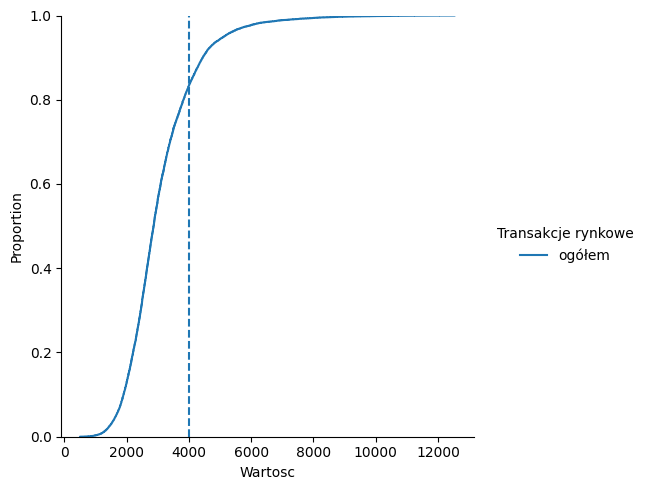

In [88]:
sns.displot(kind="ecdf", data=ogolny, x="Wartosc", hue="Transakcje rynkowe")
plt.axvline(4000, linestyle='--') 
plt.show()

Poniżej ceny 4000zł/m^3 jest sprzedawanych ok 80% mieszkań.

### Zadanie 3

Opis zbioru danych znajduje się w pliku `boston.txt`.

1. Wczytaj plik `boston.txt` (zwróć uwagę na jego format).  
   **Podpowiedź:** Skorzystaj z funkcji `read_csv` z biblioteki `pandas`, używając odpowiednich parametrów: `skiprows`, `header`, `sep`.  
   
   > Uwaga: Nie modyfikuj zawartości pliku.

2. Wyświetl funkcję masy prawdopodobieństwa dla cen mieszkań (`MEDV`).

3. Wyświetl funkcję masy prawdopodobieństwa z dwiema zmiennymi: `MEDV` (cena) i `RM` (liczba pokoi).  
   - Dla jakiej ceny i liczby pokoi sprzedaje się najwięcej mieszkań?  
   - Jakie inne informacje można wyczytać z wykresu?

4. Przeanalizuj dowolny dodatkowy atrybut i krótko opisz uzyskane wyniki.


In [140]:
col_names = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS",
    "RAD","TAX","PTRATIO","B","LSTAT","MEDV"
]

In [161]:
boston = pd.read_csv('boston.txt',
                     sep='\s+',
                     header=None,
                     skiprows=22,
                     names=col_names)

boston_new = pd.DataFrame(columns=col_names)

prev_row = None
for i, row in boston.iterrows():
    if i % 2 == 1:
        combined = np.concatenate([prev_row.values[:-3], row.values[:3]])
        boston_new.loc[len(boston_new)] = combined
    else:
        prev_row = row
    
boston_new

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


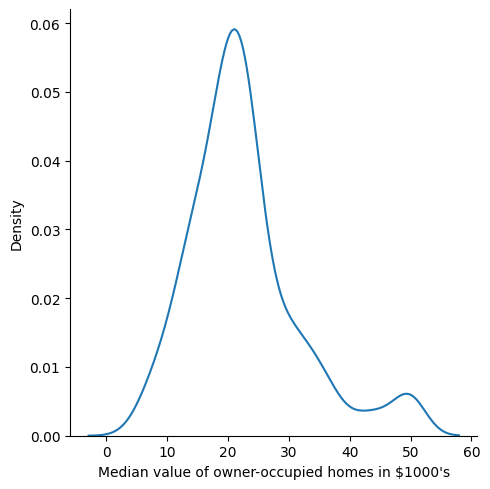

In [168]:
sns.displot(data=boston_new, x="MEDV", kind="kde")
plt.xlabel("Median value of owner-occupied homes in $1000's")
plt.show()


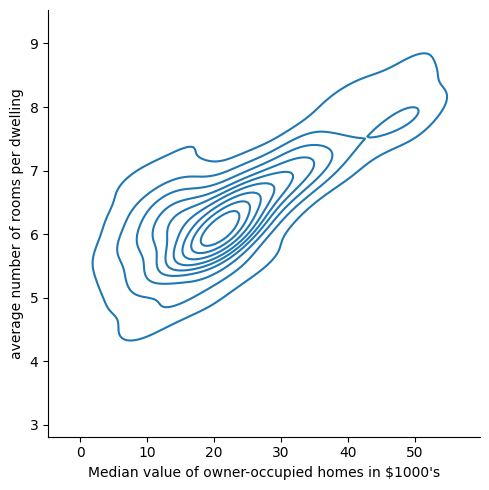

In [169]:
sns.displot(data=boston_new, x="MEDV", y="RM", kind="kde")
plt.xlabel("Median value of owner-occupied homes in $1000's")
plt.ylabel("average number of rooms per dwelling")
plt.show()
